In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/doaaalsenani/used-cars-dataets/final_cars_datasets.csv


## 1.Load Dataset

In [4]:
df = pd.read_csv("/kaggle/input/datasets/doaaalsenani/used-cars-dataets/final_cars_datasets.csv")

In [6]:
df.head()

,Unnamed: 0,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
0,0,80,nissan,march,2003,80000,1240,at,2wd,rhd,gasoline
1,1,110,nissan,march,2010,53000,1200,at,2wd,rhd,gasoline
2,2,165,nissan,lafesta,2005,47690,2000,at,2wd,rhd,gasoline
3,3,190,toyota,avensis,2008,130661,1990,at,2wd,rhd,gasoline
4,4,190,daihatsu,mira,2006,66300,660,at,2wd,rhd,gasoline


## 2. Data Quality Assessment
### 2.1 Check Data Types

In [7]:
df.dtypes

Unnamed: 0          int64
price               int64
mark               object
model              object
year                int64
mileage             int64
engine_capacity     int64
transmission       object
drive              object
hand_drive         object
fuel               object
dtype: object

In [13]:
df['year'] = pd.to_datetime(df['year'], format='%Y')

In [14]:
df.dtypes

Unnamed: 0                  int64
price                       int64
mark                       object
model                      object
year               datetime64[ns]
mileage                     int64
engine_capacity             int64
transmission               object
drive                      object
hand_drive                 object
fuel                       object
dtype: object

In [18]:
cols = ['price', 'mileage', 'engine_capacity']

for col in cols:
    df[col] = df[col].astype(str)
    df[col] = df[col].replace(r'[,\$]', '', regex=True)
    df[col] = pd.to_numeric(df[col])

In [19]:
df.dtypes

Unnamed: 0                  int64
price                       int64
mark                       object
model                      object
year               datetime64[ns]
mileage                     int64
engine_capacity             int64
transmission               object
drive                      object
hand_drive                 object
fuel                       object
dtype: object

## 3. Handling Missing Values ( Task 2 )
### 3.1 Detect Missing Values

In [20]:
df.isna()

,Unnamed: 0,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
2313,False,False,False,False,False,False,False,False,False,False,False
2314,False,False,False,False,False,False,False,False,False,False,False
2315,False,False,False,False,False,False,False,False,False,False,False
2316,False,False,False,False,False,False,False,False,False,False,False


In [21]:
df.isna().sum()

Unnamed: 0         0
price              0
mark               0
model              0
year               0
mileage            0
engine_capacity    0
transmission       0
drive              0
hand_drive         0
fuel               0
dtype: int64

### 3.2 Demonstration: Introduce Artificial Missing Values

In [22]:
df2 = df.copy()
import numpy as np

df2.loc[0:5, 'price'] = np.nan

In [23]:
df2.isna().sum()

Unnamed: 0         0
price              6
mark               0
model              0
year               0
mileage            0
engine_capacity    0
transmission       0
drive              0
hand_drive         0
fuel               0
dtype: int64

In [24]:
df2.head(10)

,Unnamed: 0,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
0,0,NaN,nissan,march,2003-01-01,80000,1240,at,2wd,rhd,gasoline
1,1,NaN,nissan,march,2010-01-01,53000,1200,at,2wd,rhd,gasoline
2,2,NaN,nissan,lafesta,2005-01-01,47690,2000,at,2wd,rhd,gasoline
3,3,NaN,toyota,avensis,2008-01-01,130661,1990,at,2wd,rhd,gasoline
4,4,NaN,daihatsu,mira,2006-01-01,66300,660,at,2wd,rhd,gasoline
5,5,NaN,daihatsu,mira,2004-01-01,81400,660,at,2wd,rhd,gasoline
6,8,220.0,nissan,march,2010-01-01,117000,1200,at,2wd,rhd,gasoline
7,9,230.0,volkswagen,passat,2008-01-01,127763,3190,at,4wd,rhd,gasoline
8,10,275.0,mazda,bongo van,2010-01-01,178218,1800,mt,2wd,rhd,gasoline
9,11,283.0,honda,step wgn,2005-01-01,121655,2000,at,2wd,rhd,gasoline


## Missing value Strategy 3: Median Imputation
### Way??

We chose median imputation because the dataset contains outliers, especially in numerical features such as price and mileage.
The median is more robust than the mean and provides a better representation of the central tendency for skewed data.

In [28]:
df_median = df2.copy()

cols = ['price', 'mileage', 'engine_capacity']

for col in cols:
    df_median[col] = df_median[col].fillna(df_median[col].median())

In [29]:
df_median.head(10)

,Unnamed: 0,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
0,0,1004.0,nissan,march,2003-01-01,80000,1240,at,2wd,rhd,gasoline
1,1,1004.0,nissan,march,2010-01-01,53000,1200,at,2wd,rhd,gasoline
2,2,1004.0,nissan,lafesta,2005-01-01,47690,2000,at,2wd,rhd,gasoline
3,3,1004.0,toyota,avensis,2008-01-01,130661,1990,at,2wd,rhd,gasoline
4,4,1004.0,daihatsu,mira,2006-01-01,66300,660,at,2wd,rhd,gasoline
5,5,1004.0,daihatsu,mira,2004-01-01,81400,660,at,2wd,rhd,gasoline
6,8,220.0,nissan,march,2010-01-01,117000,1200,at,2wd,rhd,gasoline
7,9,230.0,volkswagen,passat,2008-01-01,127763,3190,at,4wd,rhd,gasoline
8,10,275.0,mazda,bongo van,2010-01-01,178218,1800,mt,2wd,rhd,gasoline
9,11,283.0,honda,step wgn,2005-01-01,121655,2000,at,2wd,rhd,gasoline


## 4. Handling Outliers

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

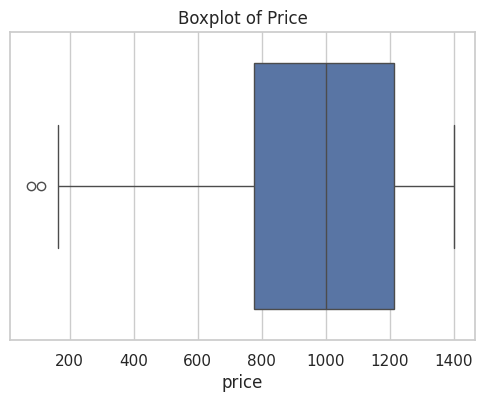

In [38]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])

plt.title('Boxplot of Price')
plt.show()

## Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

In [40]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]
outliers.head(15)

,Unnamed: 0,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
0,0,80,nissan,march,2003-01-01,80000,1240,at,2wd,rhd,gasoline
1,1,110,nissan,march,2010-01-01,53000,1200,at,2wd,rhd,gasoline


### Remove Outliers

In [41]:
df_no_outliers = df_median[(df_median['price'] >= lower) & (df_median['price'] <= upper)]

print('df with outliers: ', df_median.shape)
print('df without outliers: ', df_no_outliers.shape)

df with outliers:  (2318, 11)
df without outliers:  (2318, 11)


## 5. Data Transformation – Normalization

In [42]:
df[['price', 'mileage']].head()

,price,mileage
0,80,80000
1,110,53000
2,165,47690
3,190,130661
4,190,66300


In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['price', 'mileage']].copy()

df_scaled[['price', 'mileage']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,price,mileage
0,0.000000,0.098985
1,0.022727,0.064721
2,0.064394,0.057982
3,0.083333,0.163275
4,0.083333,0.081599


## Z-Score Normalization

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df[['price', 'mileage']].copy()

df_standardized[['price', 'mileage']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,price,mileage
0,-3.089012,-0.381195
1,-2.985066,-0.895470
2,-2.794498,-0.996610
3,-2.707876,0.583755
4,-2.707876,-0.642142


## Check Correlation Before Applying PCA

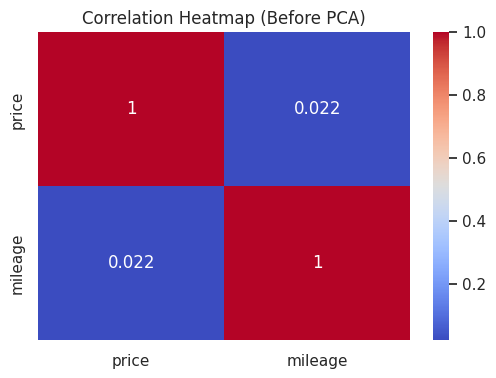

In [45]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['price', 'mileage']].corr(),
            annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap (Before PCA)")
plt.show()

## 6. Data Reduction – Principal Component Analysis (PCA)

In [46]:
from sklearn.decomposition import PCA

X = df_standardized[['price', 'mileage']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.51079044 0.48920956]


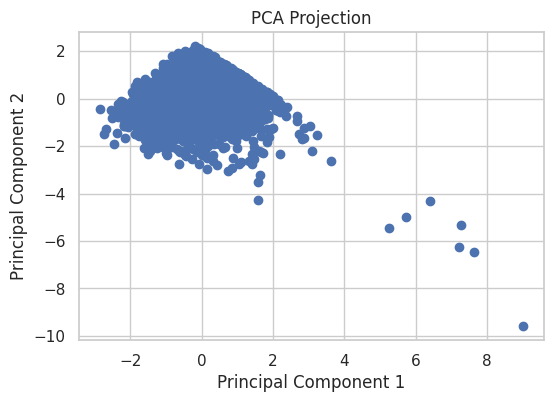

In [47]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])

plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()